# Task 3: Finetune or retrain a GNN based on quinone dataset

In [1]:
import pandas as pd
import utils
import matplotlib.pyplot as plt
import torch
from torch_geometric.nn import SchNet
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader
import torch.nn as nn
import os

/home/tatiana/miniconda3/envs/SUME_task3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data exploration

In [2]:
os.makedirs("../input", exist_ok=True)
os.chdir("../input")
# click on the link and download the file
# https://app.globus.org/file-manager?origin_id=54a78dc1-9622-4a81-8027-b2562da45cf5&origin_path=%2F
# you might need to move the file to input folder
os.chdir("../scripts")

In [3]:
# RedDB contains 3 types of datasets corresponding to the atomic properties, molecular properties and reactions properties
# Here, we only focus on the molecular properties, even though looking at the atomic and reactions properties are relevant

df_molecule=pd.read_csv('../input/RedDBv2_molecule.csv')
df_molecule.head()

,id,smiles,inchiKey,parentMolecule_id,stoichiometry,moleculer_weight,single_point_energy_solution,single_point_homo_solution,single_point_lumo_solution,single_point_energy_gas_phase,...,mmcHexadecapoleMomentsZZZX,mmcHexadecapoleMomentsZZZY,mmcHexadecapoleMomentsXXYY,mmcHexadecapoleMomentsXXZZ,mmcHexadecapoleMomentsYYZZ,mmcHexadecapoleMomentsXXYZ,mmcHexadecapoleMomentsYYXZ,mmcHexadecapoleMomentsZZXY,single_point_job_id,optimization_job_id
0,1,O=C1CC(=O)C=C1,MCFZBCCYOPSZLG-UHFFFAOYSA-N,1,C5H4O2,96.02,-342.99789,-0.22923,-0.14468,-342.98348,...,0.0000,0.0000,0.0000,6.0219,9.9036,0.0000,0.0000,0.0000,2.0,1.0
1,2,O=C1CC(=O)C(O)=C1O,FGTVOMHLQDTQAT-UHFFFAOYSA-N,1,C5H4O4,128.01,-493.33840,-0.23053,-0.13240,-493.31815,...,-6.9869,0.5577,-6.1855,-8.5944,1.7079,-1.0014,-12.2774,0.8673,4.0,3.0
2,3,O=C1CC(=O)C(F)=C1F,FXAKRDFRFAQBST-UHFFFAOYSA-N,1,C5H2O2F2,132.00,-541.29696,-0.24752,-0.15148,-541.28457,...,0.0000,0.0000,0.0000,11.6702,-45.4837,0.0000,0.0000,0.0000,6.0,5.0
3,4,O=C1CC(=O)C=C1N,GHKGYEOOXHAWTF-UHFFFAOYSA-N,1,C5NH5O2,111.03,-398.32978,-0.22211,-0.12421,-398.30573,...,0.0000,0.0000,-9.9803,1.3384,6.9082,0.0000,0.0000,-3.0407,8.0,7.0
4,5,O=C1CC(=O)C(=C1)S(=O)(=O)O,GMEKTKJXSCDXIY-UHFFFAOYSA-N,1,C5H4SO5,175.98,-966.42047,-0.24742,-0.16766,-966.39949,...,5.7817,-12.4632,-95.0165,-9.8560,-4.2151,-5.0496,13.9267,8.0979,10.0,9.0


In [4]:
print([category for category in df_molecule.columns])

['id', 'smiles', 'inchiKey', 'parentMolecule_id', 'stoichiometry', 'moleculer_weight', 'single_point_energy_solution', 'single_point_homo_solution', 'single_point_lumo_solution', 'single_point_energy_gas_phase', 'single_point_homo_gas_phase', 'single_point_lumo_gas_phase', 'solubility', 'optimization_convergence', 'optimization_energy_gas_phase', 'optimization_homo_gas_phase', 'optimization_lumo_gas_phase', 'molecular_surface', 'reaction_field_energy', 'solvent_access_surface', 'cavity_energy', 'alpha', 'dalpha', 'beta', 'nuclear_repulsion_energy', 'molecular_point_group', 'point_group_used', 'mqmwGasDipoleMomentsX', 'mqmwGasDipoleMomentsY', 'mqmwGasDipoleMomentsZ', 'mqmwGasDipoleMomentsTot', 'mqmwGasQuadrupoleMomentsXX', 'mqmwGasQuadrupoleMomentsYY', 'mqmwGasQuadrupoleMomentsZZ', 'mqmwGasQuadrupoleMomentsXY', 'mqmwGasQuadrupoleMomentsXZ', 'mqmwGasQuadrupoleMomentsYZ', 'mqmwGasTracelessQuadrupoleXXYY', 'mqmwGasTracelessQuadrupol2ZZXXYY', 'mqmwGasTracelessQuadrupoleXY', 'mqmwGasTraceles

In [5]:
df_molecule.describe()

,id,parentMolecule_id,moleculer_weight,single_point_energy_solution,single_point_homo_solution,single_point_lumo_solution,single_point_energy_gas_phase,single_point_homo_gas_phase,single_point_lumo_gas_phase,solubility,...,mmcHexadecapoleMomentsZZZX,mmcHexadecapoleMomentsZZZY,mmcHexadecapoleMomentsXXYY,mmcHexadecapoleMomentsXXZZ,mmcHexadecapoleMomentsYYZZ,mmcHexadecapoleMomentsXXYZ,mmcHexadecapoleMomentsYYXZ,mmcHexadecapoleMomentsZZXY,single_point_job_id,optimization_job_id
count,31618.000000,31618.000000,31140.000000,31140.000000,31140.000000,31140.000000,31140.000000,31140.000000,31140.000000,31618.00000,...,31088.000000,31088.000000,31088.000000,31088.000000,31088.000000,31088.000000,31088.000000,31088.000000,31140.000000,31343.000000
mean,15841.336517,15456.036688,332.183547,-1495.901177,-0.186046,-0.117872,-1495.863482,-0.183777,-0.116406,-2.90501,...,24.288619,-2.147354,53.544324,39.960364,50.107687,-2.118278,7.311554,-1.006465,31423.428003,31390.546757
std,9135.808581,9152.920479,126.704746,969.983329,0.042519,0.040976,969.977774,0.046554,0.046074,1.31031,...,328.935049,369.578875,378.399043,322.345543,340.016500,179.551261,153.479342,153.244404,18078.376622,18113.991614
min,1.000000,1.000000,68.040000,-6548.630880,-0.317270,-0.253910,-6548.578510,-0.324850,-0.276520,-6.25800,...,-3539.313500,-3750.371000,-2633.212700,-2652.896600,-3352.435300,-1476.931300,-1277.800500,-1433.100300,2.000000,1.000000
25%,7936.250000,7844.000000,242.130000,-1743.753025,-0.220830,-0.147410,-1743.720352,-0.220282,-0.149520,-3.74000,...,-35.422225,-78.168750,-28.484075,-17.161000,-27.548225,-59.333575,-35.559025,-50.322125,15812.500000,15731.000000
50%,15844.500000,15576.000000,303.990000,-1136.112760,-0.182855,-0.121590,-1136.073455,-0.182065,-0.118375,-3.03300,...,3.598600,0.000000,37.416950,19.988150,33.150850,0.000000,5.984400,-0.146300,31420.000000,31380.000000
75%,23748.750000,23612.000000,396.010000,-868.394050,-0.155920,-0.084280,-868.383517,-0.149748,-0.079350,-1.87900,...,99.630925,91.846175,178.431800,119.543825,189.732625,40.566550,68.976300,33.688900,47008.500000,47032.000000
max,31677.000000,31407.000000,937.670000,-225.943140,-0.075630,-0.018170,-225.931920,-0.056990,-0.023240,1.08800,...,2953.395200,3059.005500,2658.526300,2480.648100,1850.950900,1266.246900,1153.017900,1554.981100,64014.000000,64013.000000


In [6]:

patterns = {
    "quinone": "O=C1[#6]=C[#6](=O)[#6][#6]1",  
    "hydroxyquinone": "O=C1C=CC(=O)C=C1O",    
    "anthraquinone": "O=C1C=CC2=CC(=O)C=CC2=C1",  
    "methylquinone": "O=C1C=CC(=O)C=C1C",     
    "aminoquinone": "O=C1C=CC(=O)C=C1N", 
    "9,10anthraquinone":"O=C1C2=CC=CC=C2C(=O)C2=C1C=CC=C2",
    "1,4-Naphthoquinone": "O=C1C=CC2=C(C=CC(=O)C=2)C1",
    "2,3-Dichloro-1,4-naphthoquinone":"ClC1=CC(=O)C2=C(Cl)C(=O)C=CC2=C1",
     "2-Amino-1,4-naphthoquinone":"NC1=CC(=O)C2=C(C=CC(=O)C=2)C1",
     "2,5-Dihydroxy-1,4-benzoquinone":"O=C1C(=C(C(=O)C=C1O)O)O",
     "Tetrafluoro-1,4-benzoquinone":"F[C]1=[C](F)[C](=O)[C](=O)[C](F)=[C]1F",
     "2,3-Dimethyl-1,4-benzoquinone":"CC1=C(C)C(=O)C(=O)C=C1C",
     "1,4-Anthraquinonedisulfonic acid":"O=S(=O)(O)C1=C(C(=O)C2=CC=CC=C2C1=O)S(=O)(=O)O"
}

df_quinone_molecule = df_molecule[df_molecule["smiles"].apply(
    lambda smiles: any(utils.identify_quinone_derivatives(smiles, patterns).values()))]

In [7]:
df_quinone_molecule.head(n=5)

,id,smiles,inchiKey,parentMolecule_id,stoichiometry,moleculer_weight,single_point_energy_solution,single_point_homo_solution,single_point_lumo_solution,single_point_energy_gas_phase,...,mmcHexadecapoleMomentsZZZX,mmcHexadecapoleMomentsZZZY,mmcHexadecapoleMomentsXXYY,mmcHexadecapoleMomentsXXZZ,mmcHexadecapoleMomentsYYZZ,mmcHexadecapoleMomentsXXYZ,mmcHexadecapoleMomentsYYXZ,mmcHexadecapoleMomentsZZXY,single_point_job_id,optimization_job_id
336,339,O=C1C(N)=CC(=O)C(=C1)N,VUVVIURXJWHENR-UHFFFAOYSA-N,339,C6N2H6O2,138.04,-491.70166,-0.20097,-0.13648,-491.67331,...,0.0000,0.0000,15.2231,0.0000,0.0000,0.0000,0.0000,0.0000,678.0,677.0
337,340,O=C1C(N)=C(S(=O)(=O)O)C(=O)C(=C1)N,CJUFNCMZZBGMNC-UHFFFAOYSA-N,339,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,679.0
338,341,O=C1C(N)=C(F)C(=O)C(=C1F)N,CYXLETSBXQMCLV-UHFFFAOYSA-N,339,C6N2H4O2F2,174.02,-689.99690,-0.19949,-0.14831,-689.97075,...,0.0000,0.0000,-25.4019,0.0000,0.0000,0.0000,0.0000,0.0000,681.0,680.0
339,342,O=C1C(N)=C(N)C(=O)C(N)=C1N,DNHCPEFCQYRQQN-UHFFFAOYSA-N,339,C6N4H8O2,168.06,-602.30035,-0.14669,-0.13384,-602.26838,...,0.0000,0.0000,0.0000,0.0000,174.0465,0.0000,0.0000,0.0000,683.0,682.0
340,343,O=C1C(N)=C(S(=O)(=O)O)C(=O)C(N)=C1S(=O)(=O)O,FDEFQMIRXCLZQV-UHFFFAOYSA-N,339,C6N2H6S2O8,297.96,-1738.56427,-0.23780,-0.16608,-1738.52912,...,-28.8969,-15.7017,-248.8994,-16.1622,-119.0744,13.2048,1.8537,-83.5033,685.0,684.0


In [8]:
# cleaning the dataset to remove NAN, if the dataset was bigger, we could consider using some imputation, knn

df_quinone_molecule=df_quinone_molecule.dropna()

In [9]:
# As I will work with a pretrained QM9 model (training data computed in gas-phase), I will work with the single_point_homo_gas_phase and single_point_lumo_gas_phase, so I will only keep those features and the smiles and stochiometry
df_quinone_molecule_feature=df_quinone_molecule[["smiles","stoichiometry","single_point_homo_gas_phase","single_point_lumo_gas_phase"]]
os.makedirs("../preprocessing", exist_ok=True)
df_quinone_molecule_feature.to_csv("../preprocessing/df_quinone_mol_cleaned.csv")

In [10]:
# checking the dataframe to be sure
df_quinone_molecule_feature.head(n=5)

,smiles,stoichiometry,single_point_homo_gas_phase,single_point_lumo_gas_phase
336,O=C1C(N)=CC(=O)C(=C1)N,C6N2H6O2,-0.19767,-0.12937
338,O=C1C(N)=C(F)C(=O)C(=C1F)N,C6N2H4O2F2,-0.20100,-0.14736
339,O=C1C(N)=C(N)C(=O)C(N)=C1N,C6N4H8O2,-0.14062,-0.11909
340,O=C1C(N)=C(S(=O)(=O)O)C(=O)C(N)=C1S(=O)(=O)O,C6N2H6S2O8,-0.25282,-0.18612
341,O=C1C(N)=CC(=O)C(N)=C1C(=O)O,C7N2H6O4,-0.22310,-0.15444


## 2. Conversion to Graph and some visualisation

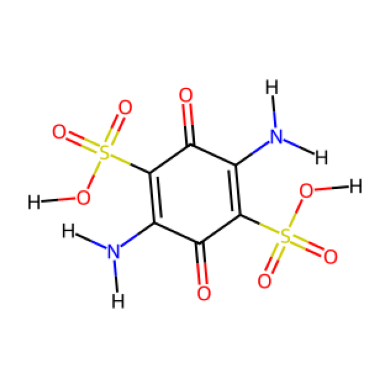

In [11]:
img = utils.plot_molecule_rdkit(df_quinone_molecule_feature.iloc[3, 0])
plt.imshow(img)
plt.axis('off')
plt.show()


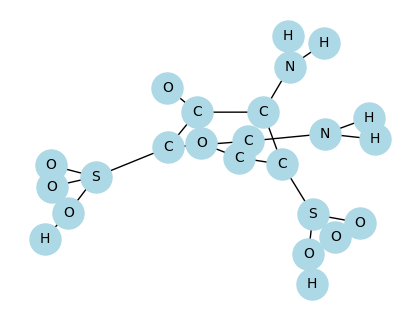

In [12]:
utils.plot_molecule_networkx(df_quinone_molecule_feature.iloc[3, 0])

In [13]:
df_graph_quinone=utils.dataframe_input_gnn(df_quinone_molecule_feature)

In [14]:
add_e_homo=df_quinone_molecule_feature[["single_point_homo_gas_phase","smiles"]]
add_e_homo["single_point_homo_gas_phase"]=add_e_homo["single_point_homo_gas_phase"]*27.2114
df_graph_quinone_e_homo=pd.merge(df_graph_quinone,add_e_homo, on='smiles')
add_e_lumo=df_quinone_molecule_feature[["single_point_lumo_gas_phase","smiles"]]
add_e_lumo["single_point_lumo_gas_phase"]=add_e_lumo["single_point_lumo_gas_phase"]*27.2114
df_graph_quinone_e_lumo=pd.merge(df_graph_quinone,add_e_lumo, on='smiles')

In [15]:
# making both input for the GNN
data_list_homo = [utils.df_row_to_data(row, "single_point_homo_gas_phase") for _, row in df_graph_quinone_e_homo.iterrows()]
data_list_lumo = [utils.df_row_to_data(row, "single_point_lumo_gas_phase") for _, row in df_graph_quinone_e_lumo.iterrows()]

[12:50:50] Molecule does not have explicit Hs. Consider calling AddHs()
[12:50:50] Molecule does not have explicit Hs. Consider calling AddHs()
[12:50:50] Molecule does not have explicit Hs. Consider calling AddHs()
[12:50:50] Molecule does not have explicit Hs. Consider calling AddHs()
[12:50:50] Molecule does not have explicit Hs. Consider calling AddHs()
[12:50:50] Molecule does not have explicit Hs. Consider calling AddHs()
[12:50:50] Molecule does not have explicit Hs. Consider calling AddHs()
[12:50:50] Molecule does not have explicit Hs. Consider calling AddHs()
[12:50:50] Molecule does not have explicit Hs. Consider calling AddHs()
[12:50:50] Molecule does not have explicit Hs. Consider calling AddHs()
[12:50:50] Molecule does not have explicit Hs. Consider calling AddHs()
[12:50:50] Molecule does not have explicit Hs. Consider calling AddHs()
[12:50:50] Molecule does not have explicit Hs. Consider calling AddHs()
[12:50:50] Molecule does not have explicit Hs. Consider calling 

## 3. First test with pretrained model without any finetuning

In [16]:
interaction_graph = utils.DenseRadiusGraph(cutoff=10.0, max_num_neighbors=32)

model = SchNet(
    hidden_channels=128,
    num_filters=128,
    num_interactions=6,
    cutoff=10.0,
    num_gaussians=50,
    interaction_graph=interaction_graph,
)
device = torch.device("cpu")


In [17]:
!ls ../models

schnet_pretrained_qm9_E_HOMO_cpu.pth  schnet_pretrained_qm9_E_LUMO_cpu.pth


In [18]:
import os
weights_path_homo = "../models/schnet_pretrained_qm9_E_HOMO_cpu.pth"
if os.path.exists(weights_path_homo):
    try:
        checkpoint = torch.load(weights_path_homo, map_location="cpu")
        model.load_state_dict(checkpoint)
        print(f"Loaded pretrained weights from: {weights_path_homo}")
    except Exception as e:
        print(f"Could not load checkpoint ({weights_path_homo}): {e}")
        print("Proceeding with randomly initialized SchNet.")
else:
        print(f"Checkpoint not found: {weights_path_homo}. Using randomly initialized SchNet.")

model_homo = model.to(device)
model_homo.eval()

Loaded pretrained weights from: ../models/schnet_pretrained_qm9_E_HOMO_cpu.pth


SchNet(hidden_channels=128, num_filters=128, num_interactions=6, num_gaussians=50, cutoff=10.0)

In [19]:
import os
weights_path_lumo = "../models/schnet_pretrained_qm9_E_LUMO_cpu.pth"
if os.path.exists(weights_path_lumo):
    try:
        checkpoint = torch.load(weights_path_lumo, map_location="cpu")
        model.load_state_dict(checkpoint)
        print(f"Loaded pretrained weights from: {weights_path_lumo}")
    except Exception as e:
        print(f"Could not load checkpoint ({weights_path_lumo}): {e}")
        print("Proceeding with randomly initialized SchNet.")
else:
        print(f"Checkpoint not found: {weights_path_lumo}. Using randomly initialized SchNet.")

model_lumo = model.to(device)
model_lumo.eval()

Loaded pretrained weights from: ../models/schnet_pretrained_qm9_E_LUMO_cpu.pth


SchNet(hidden_channels=128, num_filters=128, num_interactions=6, num_gaussians=50, cutoff=10.0)

In [20]:
df_graph_quinone_e_homo["single_point_homo_gas_phase_predicted"]=utils.prediction_model(device,data_list_homo,model_homo)

In [21]:
df_graph_quinone_e_lumo["single_point_lumo_gas_phase_predicted"]=utils.prediction_model(device,data_list_homo,model_lumo)

In [22]:
mae_homo_qm9, r2_homo_qm9, maxerror_homo_qm9, variance_score_homo_qm9, =utils.compute_metrics(df_graph_quinone_e_homo["single_point_homo_gas_phase"],df_graph_quinone_e_homo["single_point_homo_gas_phase_predicted"])
print(f"  MAE: {mae_homo_qm9:.3f}", f"  R²:  {r2_homo_qm9:.3f}",f"  Max error: {maxerror_homo_qm9:.3f}", f"  Variance score lumo:  {variance_score_homo_qm9:.3f}" )

  MAE: 50.361   R²:  -2455.043   Max error: -115.817   Variance score lumo:  73.090


In [23]:
os.makedirs("../validation", exist_ok=True)

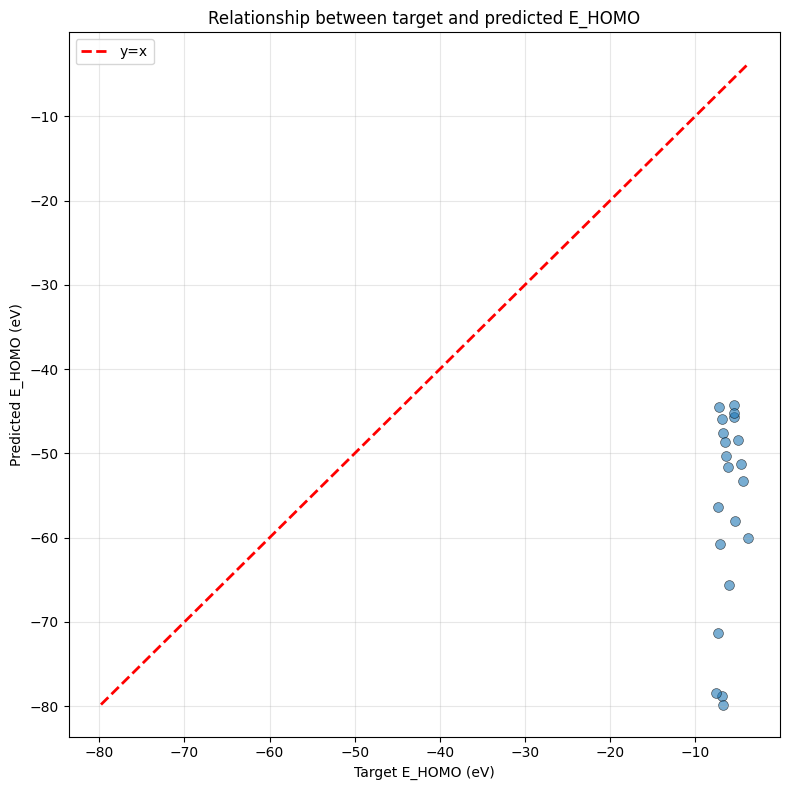

<Figure size 640x480 with 0 Axes>

In [24]:
utils.plot_regression(
    df_graph_quinone_e_homo["single_point_homo_gas_phase"],
    df_graph_quinone_e_homo["single_point_homo_gas_phase_predicted"],
    "Relationship between target and predicted E_HOMO",
    "pretrained_homo",
    "Target E_HOMO (eV)",
    "Predicted E_HOMO (eV)"
)


In [25]:
mae_lumo_qm9, r2_lumo_qm9, maxerror_lumo_qm9, variance_score_lumo_qm9, =utils.compute_metrics(df_graph_quinone_e_lumo["single_point_lumo_gas_phase"],df_graph_quinone_e_lumo["single_point_lumo_gas_phase_predicted"])
print(f"  MAE: {mae_lumo_qm9:.3f}", f"  R²:  {r2_lumo_qm9:.3f}",f"  Max error: {maxerror_lumo_qm9:.3f}", f"  Variance score lumo:  {variance_score_lumo_qm9:.3f}" )

  MAE: 51.974   R²:  -4933.562   Max error: -219.474   Variance score lumo:  74.985


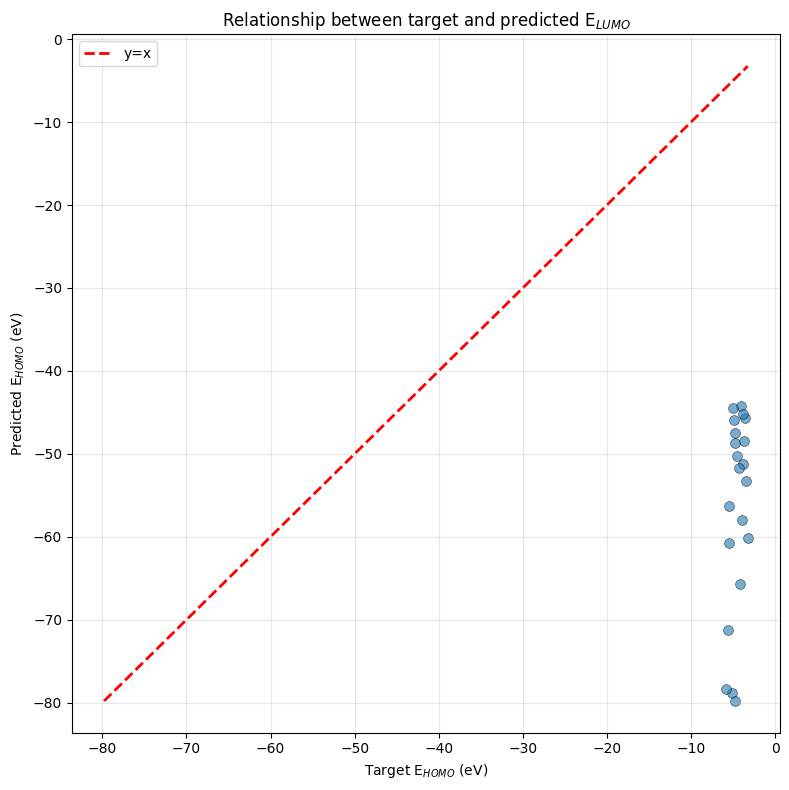

<Figure size 640x480 with 0 Axes>

In [26]:
utils.plot_regression(df_graph_quinone_e_lumo["single_point_lumo_gas_phase"],df_graph_quinone_e_lumo["single_point_lumo_gas_phase_predicted"],"Relationship between target and predicted E$_{LUMO}$","pretrained_lumo","Target E$_{HOMO}$ (eV)", "Predicted E$_{HOMO}$ (eV)")

As expected, applying the model without fine-tuning is useless and it demonstrated that the training dataset and our test are too different. In addition, the metrics shows us that the energy of the LUMO is slightly more difficult to assess, which common in DFT optimized structures.

## 4. Retraining the model

### 4.1 HOMO energies

In [27]:
indices = list(range(len(data_list_homo)))
train_idx, temp_idx = train_test_split(indices, test_size=0.5, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

retrain_train_data = [data_list_homo[i] for i in train_idx]
retrain_val_data = [data_list_homo[i] for i in val_idx]
retrain_test_data = [data_list_homo[i] for i in test_idx]

train_loader_new = DataLoader(retrain_train_data, batch_size=16, shuffle=True)
val_loader_new = DataLoader(retrain_val_data, batch_size=16, shuffle=False)
test_loader_new = DataLoader(retrain_test_data, batch_size=16, shuffle=False)


In [28]:
model_homo_finetuned = SchNet(
    hidden_channels=128,
    num_filters=128,
    num_interactions=6,
    cutoff=10.0,
    num_gaussians=50,
    interaction_graph=utils.DenseRadiusGraph(cutoff=10.0, max_num_neighbors=32),
)

model_homo_finetuned = model_homo_finetuned.to(device)
optimizer_homo_finetuned = torch.optim.Adam(model_homo_finetuned.parameters(), lr=5e-4)
criterion_homo_finetuned = nn.MSELoss()

In [29]:
num_epochs = 100
best_val_loss_f_homo = float("inf")
train_losses_f_homo = []
val_losses_f_homo = []

for epoch in range(num_epochs):
    train_loss = utils.train_epoch(model_homo_finetuned, train_loader_new, optimizer_homo_finetuned, criterion_homo_finetuned, device)
    val_loss = utils.evaluate_fresh(model_homo_finetuned, val_loader_new, criterion_homo_finetuned, device)
    
    train_losses_f_homo.append(train_loss)
    val_losses_f_homo.append(val_loss)
    
    if val_loss < best_val_loss_f_homo:
        best_val_loss_fresh = val_loss
        checkpoint_path = "../models/schnet_retrained_homo.pth"
        torch.save(model_homo_finetuned.state_dict(), checkpoint_path)

In [30]:
model_homo_finetuned.load_state_dict(torch.load("../models/schnet_retrained_homo.pth", map_location="cpu"))
model_homo_finetuned.eval()

predictions_homo = []
target_homo = []

with torch.no_grad():
    for batch in test_loader_new:
        batch = batch.to(device)
        pred = model_homo_finetuned(batch.z, batch.pos, batch.batch)
        predictions_homo.extend(pred.view(-1).cpu().numpy())
        target_homo.extend(batch.y.view(-1).cpu().numpy())

In [31]:
mae_homo_r, r2_homo_r, maxerror_homo_r, variance_score_homo_r, =utils.compute_metrics(target_homo,predictions_homo)
print(f"  MAE: {mae_homo_r:.3f}", f"  R²:  {r2_homo_r:.3f}",f"  Max error: {maxerror_homo_r:.3f}", f"  Variance score:  {variance_score_homo_r:.3f}") 

  MAE: 0.615   R²:  0.153   Max error: 0.699   Variance score:  1.441


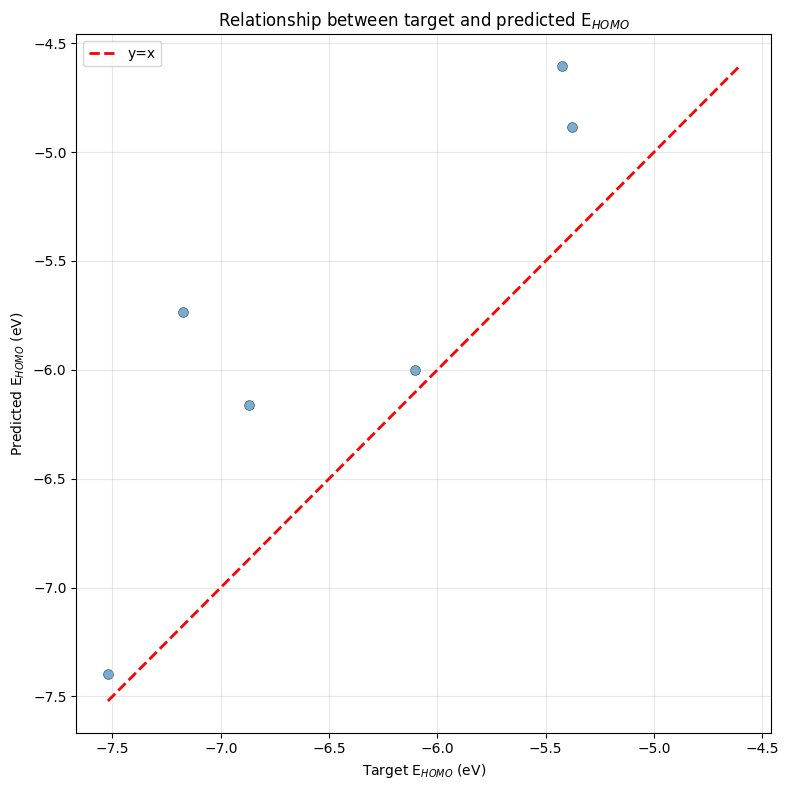

<Figure size 640x480 with 0 Axes>

In [32]:
utils.plot_regression(target_homo, predictions_homo,"Relationship between target and predicted E$_{HOMO}$","retrained_homo","Target E$_{HOMO}$ (eV)", "Predicted E$_{HOMO}$ (eV)")

### 4.2 LUMO energies

In [33]:
indices = list(range(len(data_list_lumo)))
train_idx, temp_idx = train_test_split(indices, test_size=0.5, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

retrain_train_data = [data_list_lumo[i] for i in train_idx]
retrain_val_data = [data_list_lumo[i] for i in val_idx]
retrain_test_data = [data_list_lumo[i] for i in test_idx]

train_loader_new = DataLoader(retrain_train_data, batch_size=16, shuffle=True)
val_loader_new = DataLoader(retrain_val_data, batch_size=16, shuffle=False)
test_loader_new = DataLoader(retrain_test_data, batch_size=16, shuffle=False)


In [34]:
model_lumo_finetuned = SchNet(
    hidden_channels=128,
    num_filters=128,
    num_interactions=6,
    cutoff=10.0,
    num_gaussians=50,
    interaction_graph=utils.DenseRadiusGraph(cutoff=10.0, max_num_neighbors=32),
)

model_lumo_finetuned = model_lumo_finetuned.to(device)
optimizer_lumo_finetuned = torch.optim.Adam(model_lumo_finetuned.parameters(), lr=5e-4)
criterion_lumo_finetuned = nn.MSELoss()

In [35]:
num_epochs = 100
best_val_loss_f_lumo = float("inf")
train_losses_f_lumo = []
val_losses_f_lumo = []

for epoch in range(num_epochs):
    train_loss = utils.train_epoch(model_lumo_finetuned, train_loader_new, optimizer_lumo_finetuned, criterion_lumo_finetuned, device)
    val_loss = utils.evaluate_fresh(model_lumo_finetuned, val_loader_new, criterion_lumo_finetuned, device)
    
    train_losses_f_lumo.append(train_loss)
    val_losses_f_lumo.append(val_loss)
    
    if val_loss < best_val_loss_f_lumo:
        best_val_loss_fresh = val_loss
        checkpoint_path = "../models/schnet_retrained_lumo.pth"
        torch.save(model_lumo_finetuned.state_dict(), checkpoint_path)

In [36]:
model_lumo_finetuned.load_state_dict(torch.load("../models/schnet_retrained_lumo.pth", map_location="cpu"))
model_lumo_finetuned.eval()

predictions_lumo = []
target_lumo = []

with torch.no_grad():
    for batch in test_loader_new:
        batch = batch.to(device)
        pred = model_lumo_finetuned(batch.z, batch.pos, batch.batch)
        predictions_lumo.extend(pred.view(-1).cpu().numpy())
        target_lumo.extend(batch.y.view(-1).cpu().numpy())

In [37]:
mae_lumo_r, r2_lumo_r, maxerror_lumo_r, variance_score_lumo_r, =utils.compute_metrics(target_lumo,predictions_lumo)
print(f"  MAE: {mae_lumo_r:.3f}", f"  R²:  {r2_lumo_r:.3f}",f"  Max error: {maxerror_lumo_r:.3f}", f"  Variance score lumo:  {variance_score_lumo_r:.3f}" )

  MAE: 0.849   R²:  -0.623   Max error: 0.478   Variance score lumo:  1.759


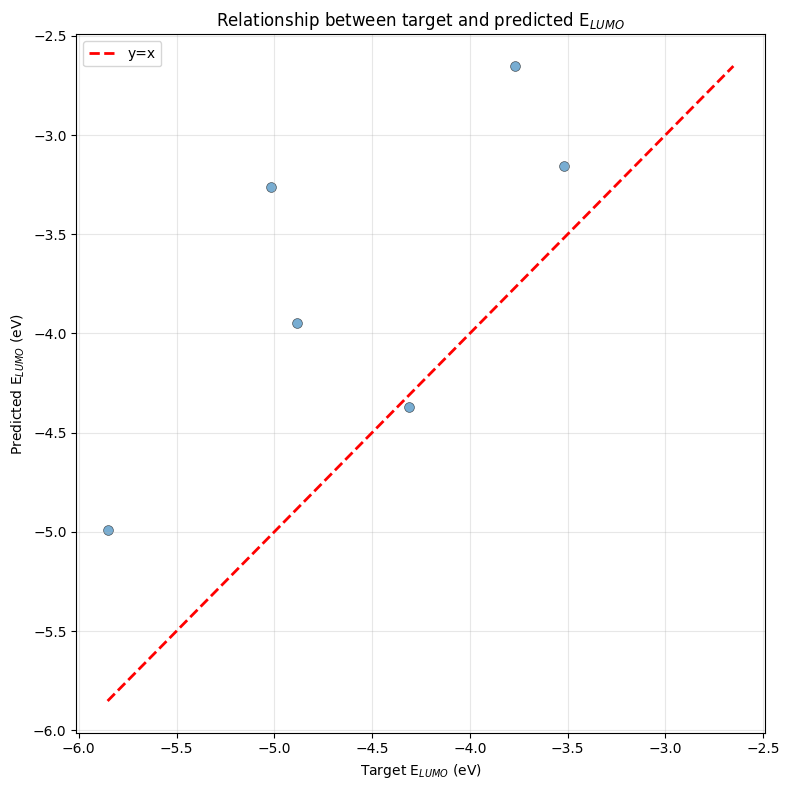

<Figure size 640x480 with 0 Axes>

In [38]:
utils.plot_regression(target_lumo, predictions_lumo, "Relationship between target and predicted E$_{LUMO}$","retrained_lumo","Target E$_{LUMO}$ (eV)", "Predicted E$_{LUMO}$ (eV)")

- In general, retraining the model improves  its accuracy and the metrics. 
- However, the accuracy of the model is random as the test and training are split randomly.
- Hence, running this notebook several times provides different answers, demonstrating the lack of reproducibility of this GNN.
- The R2 values for E(HOMO) vary from [<-.1, 0.83], while The R2 values for E(LUMO) ranges from [<-1,0.76].
- To improve the learning of the model, the data should have been normalized
- This shows that the dataset is too small in general and that E(LUMO) is more difficult to evaluate than E(HOMO)

## 5. Conclusion

GNN are promising tools to predict properties based on structures.
However, the data curation and the input cannot be neglected, otherwise the output would be worthless